# Short-Term Synaptic Dynamics

## Motivation

In previous notebooks, synaptic strength was treated as fixed. However, biological synapses often change their efficacy dynamically depending on recent activity.

Short-term synaptic dynamics operate over relatively fast timescales and can temporarily strengthen or weaken synaptic transmission. These mechanisms influence how neural systems process repeated input over time.

## Fixed Synaptic Strength vs Dynamic Synaptic Strength

A fixed synaptic model assumes that every presynaptic spike produces the same postsynaptic effect. In contrast, dynamic synaptic models allow synaptic efficacy to change as a function of recent activity.

One important example is short-term synaptic depression, where repeated presynaptic spikes temporarily reduce synaptic efficacy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Time parameters
T = 250           # total simulation time (ms)
dt = 0.1          # simulation time step (ms)
time = np.arange(0, T, dt)

# Presynaptic spike times
presynaptic_spike_times = [30, 50, 70, 90, 110, 130, 170, 210]

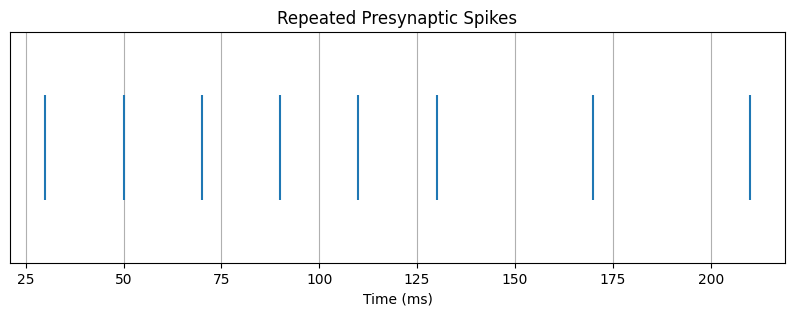

In [3]:
plt.figure(figsize=(10, 3))
plt.eventplot(presynaptic_spike_times, lineoffsets=1, linelengths=0.6)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Repeated Presynaptic Spikes")
plt.grid(True)
plt.show()

## Short-Term Synaptic Depression

In this simplified model, synaptic efficacy decreases after each presynaptic spike and then gradually recovers over time.

The depression variable $D(t)$ represents the available synaptic efficacy:

$$
0 \leq D(t) \leq 1
$$

Each spike reduces $D(t)$, while recovery drives it back toward 1.

In [4]:
# Depression parameters
recovery_tau = 40.0      # recovery time constant (ms)
depression_factor = 0.75

# Initialize depression dynamics
D = np.ones_like(time)
current_D = 1.0

# Spike indices
spike_indices = [int(spike_time / dt) for spike_time in presynaptic_spike_times]

In [5]:
for i in range(1, len(time)):

    # Recovery toward baseline
    dD = (1.0 - current_D) / recovery_tau
    current_D += dt * dD

    # Depression triggered by spikes
    if i in spike_indices:
        current_D *= depression_factor

    D[i] = current_D

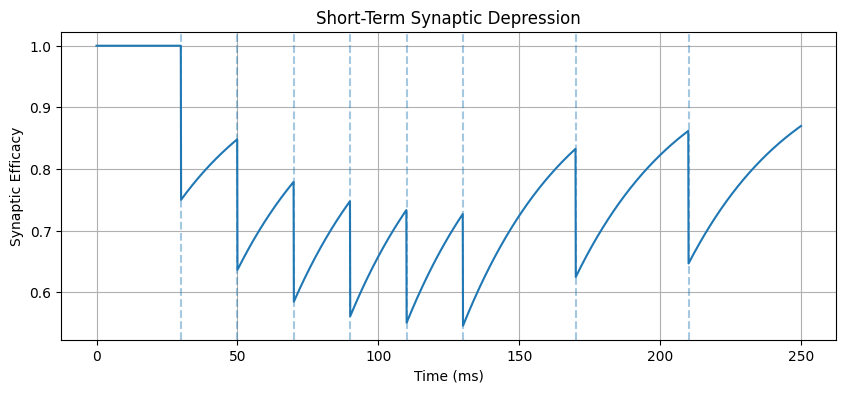

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(time, D)

for spike_time in presynaptic_spike_times:
    plt.axvline(spike_time, linestyle="--", alpha=0.4)

plt.xlabel("Time (ms)")
plt.ylabel("Synaptic Efficacy")
plt.title("Short-Term Synaptic Depression")
plt.grid(True)
plt.show()

Repeated spikes progressively reduce synaptic efficacy, while pauses between spikes allow partial recovery. This creates a history-dependent synaptic response.

## Effect of Repeated Presynaptic Spikes

The depressed synaptic efficacy can now be used to scale the amplitude of synaptic current generated by each spike.

In [7]:
def alpha_current(time, spike_time, amplitude=1.0, tau_syn=10.0):
    """
    Compute an alpha-function synaptic current triggered by one presynaptic spike.
    """
    current = np.zeros_like(time)

    for i, t in enumerate(time):
        if t >= spike_time:
            time_since_spike = t - spike_time
            current[i] = amplitude * (time_since_spike / tau_syn) * np.exp(1 - time_since_spike / tau_syn)

    return current

In [8]:
# Synaptic current parameters
base_weight = 1.5
tau_syn = 10.0

synaptic_current = np.zeros_like(time)

# Store efficacy values at spike times
spike_efficacies = []

for spike_time in presynaptic_spike_times:
    spike_index = int(spike_time / dt)
    efficacy = D[spike_index]
    spike_efficacies.append(efficacy)

    synaptic_current += alpha_current(
        time=time,
        spike_time=spike_time,
        amplitude=base_weight * efficacy,
        tau_syn=tau_syn
    )

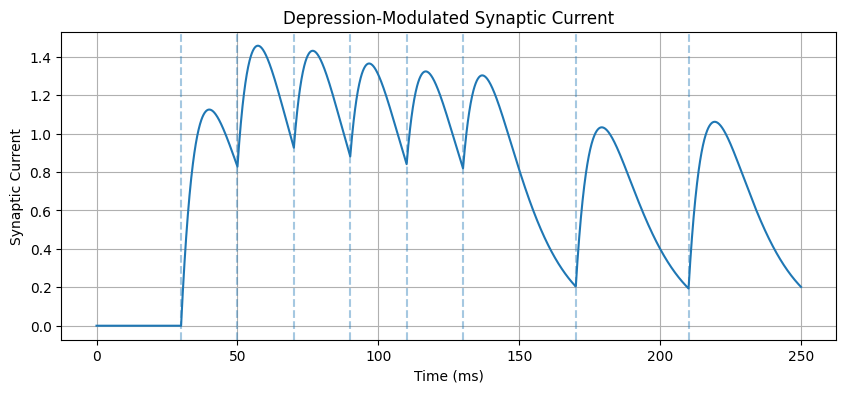

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time, synaptic_current)

for spike_time in presynaptic_spike_times:
    plt.axvline(spike_time, linestyle="--", alpha=0.4)

plt.xlabel("Time (ms)")
plt.ylabel("Synaptic Current")
plt.title("Depression-Modulated Synaptic Current")
plt.grid(True)
plt.show()

Because synaptic efficacy decreases during repeated activity, later spikes generate weaker postsynaptic currents. This means that synaptic output depends not only on current spikes, but also on recent spike history.

## Postsynaptic Response Under Synaptic Depression

We can now inject the depression-modulated synaptic current into a postsynaptic LIF neuron.

In [10]:
# Postsynaptic LIF neuron parameters
V_rest = -70.0
V_reset = -65.0
V_th = -50.0
tau_m = 10.0
R = 10.0

postsynaptic_voltage = np.zeros_like(time)
postsynaptic_voltage[0] = V_rest

postsynaptic_spike_times = []

In [11]:
for i in range(1, len(time)):

    dV = dt / tau_m * (-(postsynaptic_voltage[i - 1] - V_rest) + R * synaptic_current[i - 1]
    )

    postsynaptic_voltage[i] = postsynaptic_voltage[i - 1] + dV

    if postsynaptic_voltage[i] >= V_th:
        postsynaptic_spike_times.append(time[i])
        postsynaptic_voltage[i] = V_reset

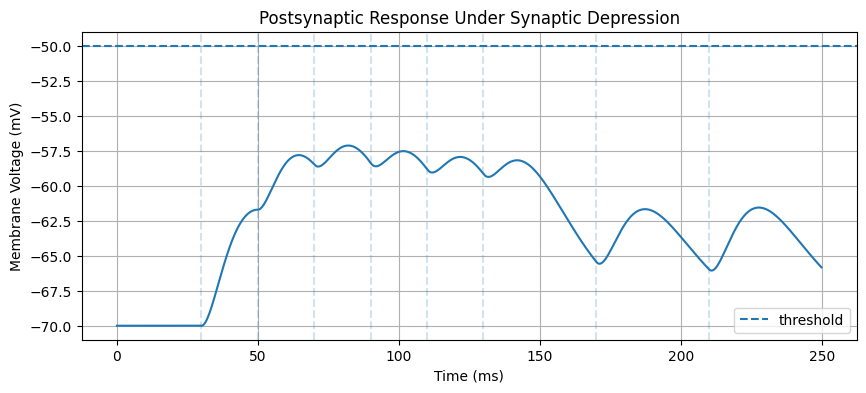

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(time, postsynaptic_voltage)
plt.axhline(V_th, linestyle="--", label="threshold")

for spike_time in presynaptic_spike_times:
    plt.axvline(spike_time, linestyle="--", alpha=0.2)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Postsynaptic Response Under Synaptic Depression")
plt.grid(True)
plt.legend()
plt.show()

The postsynaptic response now depends on the recent history of presynaptic activity. Closely spaced spikes can produce progressively weaker responses because synaptic efficacy temporarily decreases.

## Limitations

This model uses a simplified phenomenological description of short-term depression rather than a detailed biophysical model of vesicle depletion or presynaptic release dynamics.

The presynaptic spike train is predefined, and the synapse is modeled with an alpha-function current rather than conductance-based receptor dynamics. Despite these simplifications, the model captures the important idea that synaptic transmission can depend strongly on recent activity history.

## Connection to STDP

Short-term synaptic dynamics temporarily change synaptic efficacy over relatively fast timescales. The next step is to study long-term activity-dependent synaptic modification.

This leads naturally to spike-timing dependent plasticity (STDP), where the relative timing of pre- and postsynaptic spikes determines whether synaptic weights increase or decrease over time.